In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.signal as signal
import sys
import os
sys.path.append(os.path.abspath(".."))
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneGroupOut, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

%load_ext autoreload
%autoreload 2
import src.features as features

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data and Extract Features

In [2]:
df = pd.read_csv("../data/intermediate/pamap_cleaned_df.csv")

X , y, subjects = features.pull_features_per_subject(df)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

## Model Training

In [3]:
# XGBoost Classifier
XGB_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric="mlogloss", random_state=42)

# Random Forest Classifier
RF_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, n_jobs=-1, random_state=42)

# Regression Tree Classifier
DT_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

# Logistic Regression Classifier
LR_model = Pipeline([
("scaler", StandardScaler()),
("model", LogisticRegression(max_iter=5000, random_state=42))
])

models = {
    "DecisionTree": DT_model,
    "RandomForest": RF_model,
    "XGBoost": XGB_model,
    "LogisticRegression": LR_model
}

In [5]:
def LOGO_model_training(X, y_encoded, subjects, model):
    """Train a model using Leave-One-Group-Out cross-validation and return true and predicted labels."""
   
    logo = LeaveOneGroupOut()
    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in logo.split(X, y, groups=subjects):
        print(f"Train subjects: {set(subjects[train_idx])}, Test subject: {set(subjects[test_idx])}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        # train model
        model.fit(X_train, y_train)

        # predict
        y_pred = model.predict(X_test)
        #print(classification_report(y_test, y_pred, zero_division=0))

        # accumulate
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    return all_y_true, all_y_pred

In [6]:
model_results = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    y_true, y_pred = LOGO_model_training(X, y_encoded, subjects, model)
    model_results[model_name] = (y_true, y_pred)

Training DecisionTree...
Train subjects: {1, 2, 3, 4, 5, 6, 7, 8}, Test subject: {0}
Train subjects: {0, 2, 3, 4, 5, 6, 7, 8}, Test subject: {1}
Train subjects: {0, 1, 3, 4, 5, 6, 7, 8}, Test subject: {2}
Train subjects: {0, 1, 2, 4, 5, 6, 7, 8}, Test subject: {3}
Train subjects: {0, 1, 2, 3, 5, 6, 7, 8}, Test subject: {4}
Train subjects: {0, 1, 2, 3, 4, 6, 7, 8}, Test subject: {5}
Train subjects: {0, 1, 2, 3, 4, 5, 7, 8}, Test subject: {6}
Train subjects: {0, 1, 2, 3, 4, 5, 6, 8}, Test subject: {7}
Train subjects: {0, 1, 2, 3, 4, 5, 6, 7}, Test subject: {8}
Training RandomForest...
Train subjects: {1, 2, 3, 4, 5, 6, 7, 8}, Test subject: {0}
Train subjects: {0, 2, 3, 4, 5, 6, 7, 8}, Test subject: {1}
Train subjects: {0, 1, 3, 4, 5, 6, 7, 8}, Test subject: {2}
Train subjects: {0, 1, 2, 4, 5, 6, 7, 8}, Test subject: {3}
Train subjects: {0, 1, 2, 3, 5, 6, 7, 8}, Test subject: {4}
Train subjects: {0, 1, 2, 3, 4, 6, 7, 8}, Test subject: {5}
Train subjects: {0, 1, 2, 3, 4, 5, 7, 8}, Test sub

Confusion Matrix for DecisionTree:


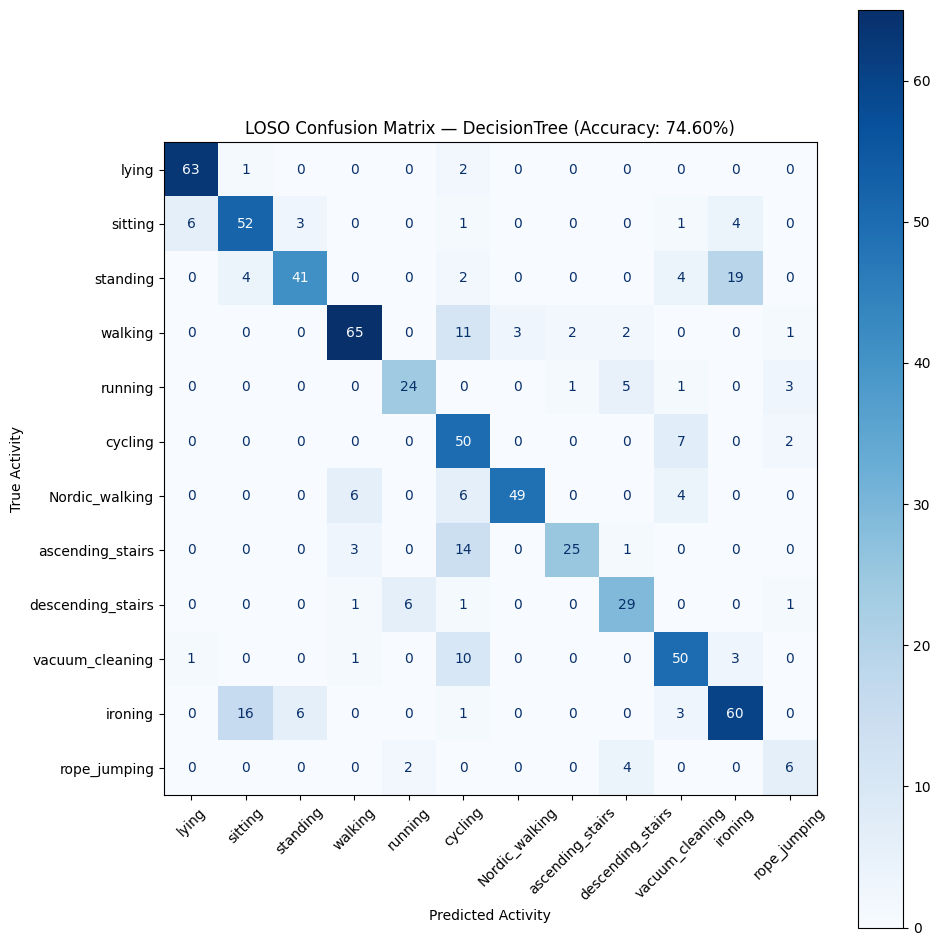

Confusion Matrix for RandomForest:


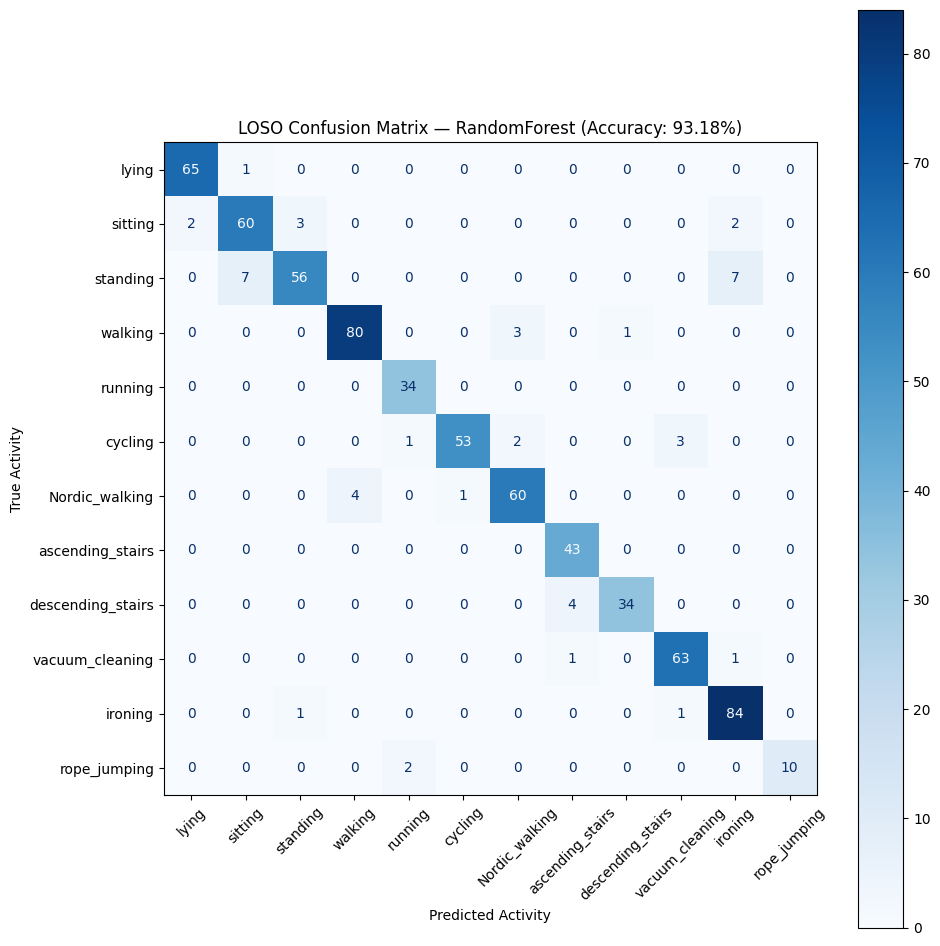

Confusion Matrix for XGBoost:


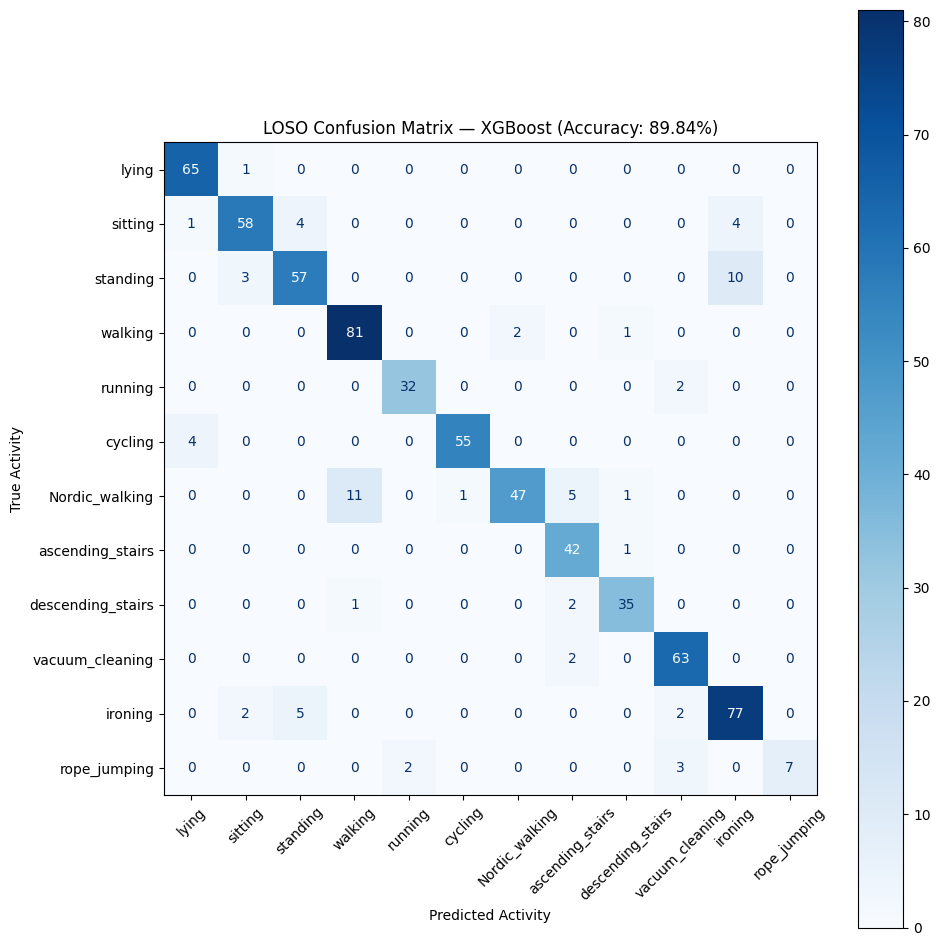

Confusion Matrix for LogisticRegression:


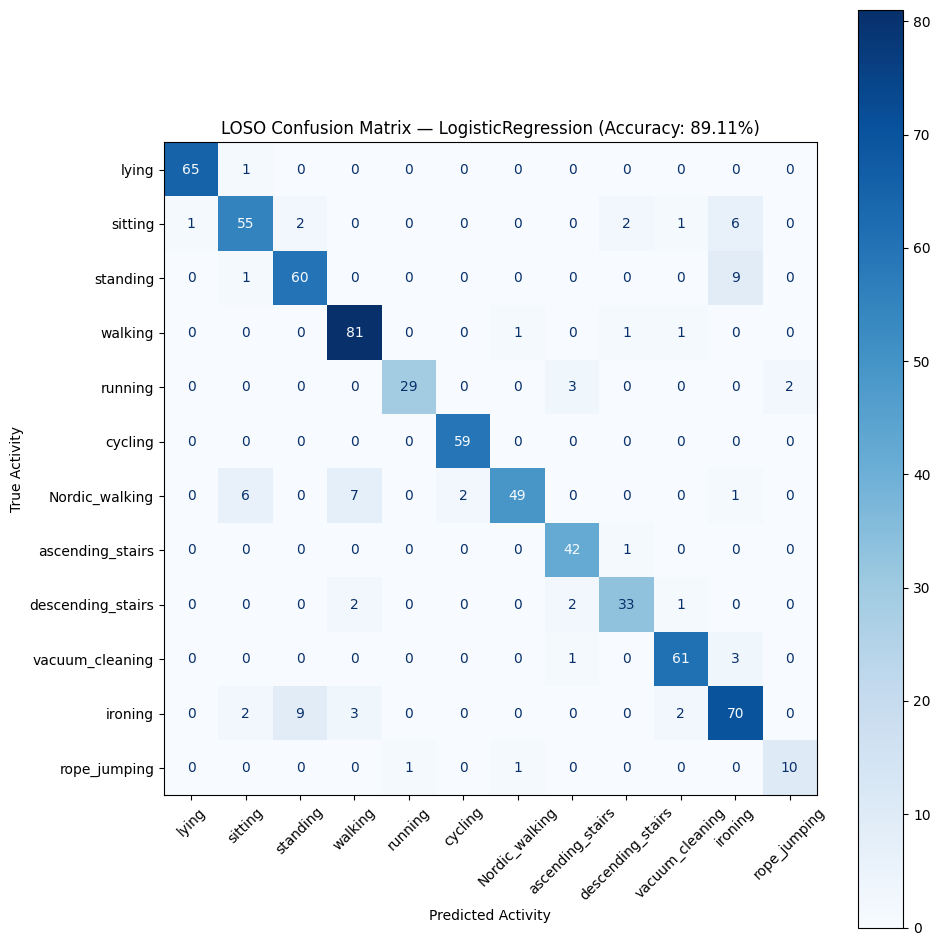

In [19]:
def plot_confusion_matrix_with_accuracy_score(y_true, y_pred, model_name, encoder):
    labels = np.unique(np.concatenate([y_true, y_pred]))

    cm = confusion_matrix(y_true, y_pred,labels=labels)

    # Convert encoded labels to PAMAP activity IDs
    original_labels = encoder.inverse_transform(labels)

    display_labels = [features.ACTIVITY_LABEL_MAP[int(label)] for label in original_labels]

    accuracy = accuracy_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(xticks_rotation=45, ax=ax, cmap=plt.cm.Blues)
    ax.set_title(f"LOSO Confusion Matrix — {model_name} " f"(Accuracy: {accuracy:.2%})")
    ax.set_xlabel("Predicted Activity")
    ax.set_ylabel("True Activity")
    plt.tight_layout()
    plt.savefig(f"../data/results/{model_name}_confusion_matrix.png")
    plt.show()


for model_name, (y_true, y_pred) in model_results.items():
    print(f"Confusion Matrix for {model_name}:")

    plot_confusion_matrix_with_accuracy_score(
        y_true,
        y_pred,
        model_name,
        encoder
    )

In [161]:
# importances =XGB_model.feature_importances_
# feature_names = X.columns

# plt.figure(figsize=(12, 30), layout="tight")
# plt.barh(feature_names, importances)
# plt.xlabel("Feature Importance")
# plt.ylabel("Feature")
# plt.title("Feature Importances from XGBoost")

In [162]:
# from sklearn.inspection import permutation_importance

# r = permutation_importance(
#     XGB_model,
#     X_test,
#     y_test,
#     n_repeats=10,
#     random_state=42,
#     n_jobs=-1
# )

# global_importance = pd.Series(r.importances_mean, index=X.columns)

In [163]:
# class_importance = {}

# for c in np.unique(y_test):
#     mask = y_test == c

#     if mask.sum() < 5:
#         continue

#     r = permutation_importance(
#         XGB_model,
#         X_test[mask],
#         y_test[mask],
#         n_repeats=5,
#         random_state=42,
#         n_jobs=-1
#     )

#     class_importance[c] = r.importances_mean

In [164]:
# importance_df = pd.DataFrame(class_importance, index=X.columns)
# importance_df.columns = [pf.ACTIVITY_LABEL_MAP[c] for c in importance_df.columns]
# plt.figure(figsize=(12, 30))
# sns.heatmap(importance_df, cmap="viridis")
# plt.title("Feature Importance by Activity")
# plt.show()

## Hyperparameter Optimization

In [14]:
# baseline model
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

# paramter distribution for randomized search
param_dist = {
    "n_estimators": [100, 200, 300], #number of trees
    "max_depth": [3, 5, 7, 9], #max depth of each tree
    "learning_rate": [0.01, 0.03, 0.05, 0.1], #learning aggressiveness
    "subsample": [0.6, 0.8, 1.0], #fraction of samples used for training each tree
    "colsample_bytree": [0.6, 0.8, 1.0], #fraction of features used for training each tree
    "min_child_weight": [1, 3, 5], #minimum sum of instance weights needed in a child
    "gamma": [0, 0.1, 0.3] #minimum loss reduction required to make a further partition/split gain
}

In [15]:
#use randomized search cv to find optimal hyperparameters for XGBoost
search = RandomizedSearchCV(estimator=xgb,
                            param_distributions=param_dist,
                            n_iter=20, #number of parameter settings that are sampled
                            cv = LeaveOneGroupOut(), #use LOSO cross-validation
                            scoring = 'f1_macro', #use macro F1 score for multi-class classification
                            n_jobs=-1,
                            verbose=2,                    
                            random_state=42
                            )

search.fit(X, y_encoded, groups=subjects)

print(search.best_params_)
print(search.best_score_)

display(pd.DataFrame(search.cv_results_))

Fitting 9 folds for each of 20 candidates, totalling 180 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.6; total time=   6.0s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.6; total time=   6.1s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.6; total time=   6.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.6; total time=   6.3s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.6; total time=   6.4s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.03, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.6; total time=   6.4s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_gamma,...,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,mean_test_score,std_test_score,rank_test_score
0,6.279135,0.258556,0.032952,0.016516,0.6,300,3,5,0.03,0.1,...,0.991718,0.962382,0.944861,0.914157,0.766153,0.710758,0.885431,0.895377,0.093426,7
1,8.585698,0.399645,0.033512,0.019331,0.6,300,5,5,0.01,0.3,...,0.981102,0.942537,0.956007,0.825861,0.667729,0.731611,0.868887,0.742881,0.283507,19
2,1.957904,0.127706,0.013934,0.008724,1.0,200,5,9,0.10,0.1,...,0.991718,0.945649,0.927181,0.902964,0.719746,0.765957,0.885431,0.888125,0.089888,11
3,2.042416,0.120523,0.014145,0.004399,0.8,300,5,9,0.10,0.3,...,0.991718,0.962382,0.927181,0.902964,0.708555,0.777290,0.900586,0.896016,0.091080,5
4,2.573772,0.130916,0.008685,0.003604,1.0,200,5,5,0.05,0.3,...,0.974624,0.962382,0.927181,0.902964,0.744794,0.746598,0.885431,0.895661,0.087025,6
5,2.842411,0.112503,0.010835,0.007789,0.6,300,3,3,0.05,0.3,...,0.991718,0.962382,0.927181,0.914157,0.774956,0.853013,0.913917,0.916439,0.065795,2
6,2.532623,0.113896,0.027899,0.026115,0.8,100,5,9,0.05,0.3,...,0.991718,0.962382,0.927181,0.843462,0.744439,0.721837,0.885431,0.875295,0.098127,16
7,10.088687,0.326114,0.020682,0.006004,1.0,200,3,7,0.01,0.1,...,0.870154,0.952281,0.923781,0.849409,0.744179,0.686077,0.857712,0.852509,0.094637,18
8,1.241208,0.076878,0.012331,0.005908,0.6,100,5,3,0.10,0.0,...,0.825742,0.952638,0.944861,0.904869,0.663249,0.770383,0.925683,0.869227,0.099697,17
9,2.976665,0.095004,0.011932,0.003473,0.6,100,3,3,0.01,0.3,...,0.874766,0.952638,0.943626,0.747437,0.609966,0.557115,0.897440,0.697283,0.281556,20


## Final Model

In [20]:
# train final model with optimal hyperparameters
optimal_params = search.best_params_
XGB_model_final = XGBClassifier(**optimal_params)
XGB_model_final.fit(X, y_encoded) 

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [21]:
y_pred = XGB_model_final.predict(X)
print(classification_report(y_encoded, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        67
           2       1.00      1.00      1.00        70
           3       1.00      1.00      1.00        84
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00        59
           6       1.00      1.00      1.00        65
           7       1.00      1.00      1.00        43
           8       1.00      1.00      1.00        38
           9       1.00      1.00      1.00        65
          10       1.00      1.00      1.00        86
          11       1.00      1.00      1.00        12

    accuracy                           1.00       689
   macro avg       1.00      1.00      1.00       689
weighted avg       1.00      1.00      1.00       689



In [169]:
# save to model folder
joblib.dump(XGB_model_final, "../models/xgb_activity_classifier.pkl")

# save encoder
joblib.dump(encoder, "../models/activity_label_encoder.pkl")

# save feature order
joblib.dump(X.columns.tolist(), "../models/feature_order.pkl")

['../models/feature_order.pkl']

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

xgb_accuracy = accuracy_score(y_true, y_pred)

xgb_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"XGB Accuracy: {xgb_accuracy:.4f}")
print(f"XGB Macro F1: {xgb_f1:.4f}")

XGB Accuracy: 1.0000
XGB Macro F1: 1.0000


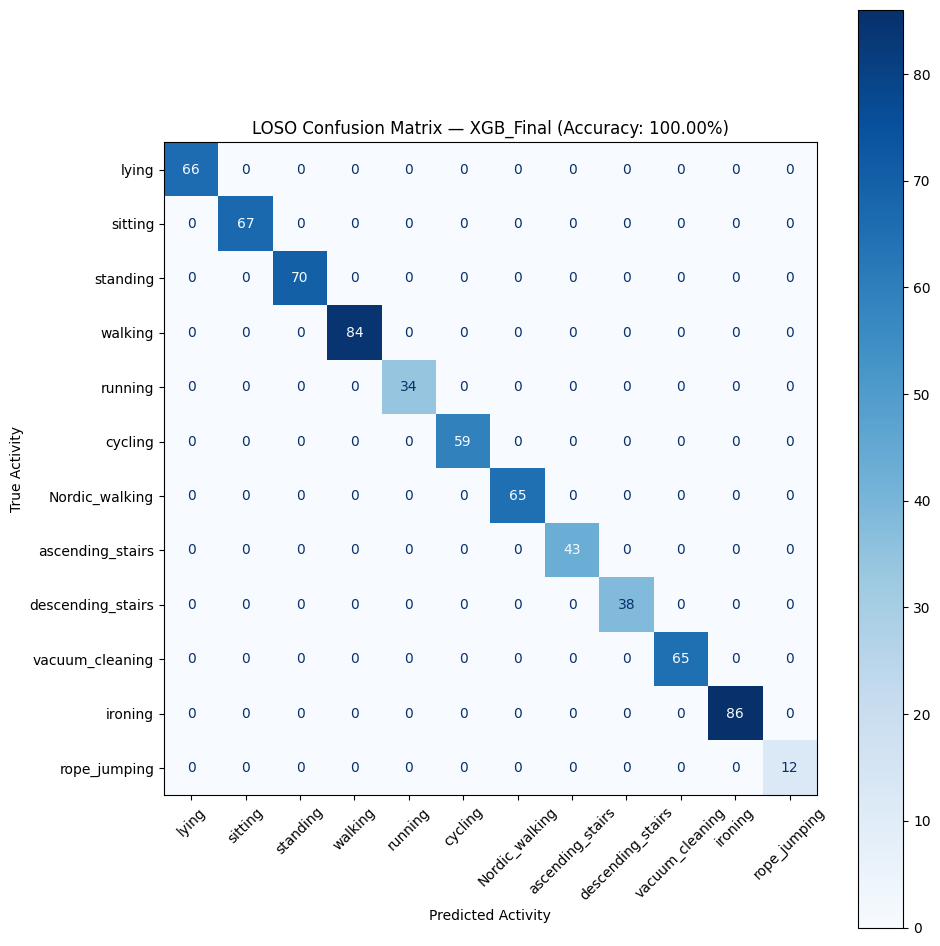

In [22]:
plot_confusion_matrix_with_accuracy_score(
        y_true,
        y_pred,
        model_name="XGB_Final",
        encoder=encoder
    )